In [1]:
# Author: Arthur Prigent
# Email: arthur.prigent@univ-brest.fr

In [1]:
import matplotlib.patches as mpatches
from scipy.stats import pearsonr
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy
import matplotlib
import scipy
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib.colors as mcolors

from datetime import datetime, timedelta
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import glob
import matplotlib.pyplot as plt
import netCDF4
import string
from scipy.spatial import cKDTree
from datetime import timedelta
import gsw

### PSAL

In [2]:
ds_all_psal = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_2/profiles_QC_PSAL_new.nc',decode_times=False)

### TEMP

In [3]:
ds_all_temp = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_2/profiles_QC_TEMP_new.nc',decode_times=False)

In [4]:
def build_key(ds):
    # safer precision: avoid too coarse rounding
    time   = np.char.mod('%.5f', ds.time.values)
    lat    = np.char.mod('%.5f', ds.latitude.values)
    lon    = np.char.mod('%.5f', ds.longitude.values)
    source = ds.source.values.astype(str)

    key = np.char.add(time, "_")
    key = np.char.add(key, lat)
    key = np.char.add(key, "_")
    key = np.char.add(key, lon)
    key = np.char.add(key, "_")
    key = np.char.add(key, source)

    return key


def drop_duplicate_profiles(ds):
    key = build_key(ds)
    _, unique_idx = np.unique(key, return_index=True)
    n_before = ds.profile.size
    ds_deduped = ds.isel(profile=unique_idx)
    n_dropped = n_before - ds_deduped.profile.size
    print(f"Dropped {n_dropped} duplicate profiles, {ds_deduped.profile.size} remaining")
    return ds_deduped

ds_temp_test = drop_duplicate_profiles(ds_all_temp)
ds_psal_test = drop_duplicate_profiles(ds_all_psal)

Dropped 0 duplicate profiles, 318918 remaining
Dropped 0 duplicate profiles, 309358 remaining


In [5]:
# --- Find common profiles ---
key_temp = build_key(ds_all_temp)
key_psal = build_key(ds_all_psal)

common_keys = np.intersect1d(key_temp, key_psal)

ds_temp_common = ds_all_temp.isel(profile=np.isin(key_temp, common_keys))
ds_psal_common = ds_all_psal.isel(profile=np.isin(key_psal, common_keys))

print(f"Common profiles: {ds_temp_common.profile.size}")

Common profiles: 303355


In [6]:
ds_temp_common["source"] = ds_temp_common["source"].astype(str)
ds_psal_common["source"] = ds_psal_common["source"].astype(str)

In [ ]:
ds_temp_common.to_netcdf('/data0/user/aprigent/PROCESSED/level_3/temp_common_full.nc')
ds_psal_common.to_netcdf('/data0/user/aprigent/PROCESSED/level_3/psal_common_full.nc')

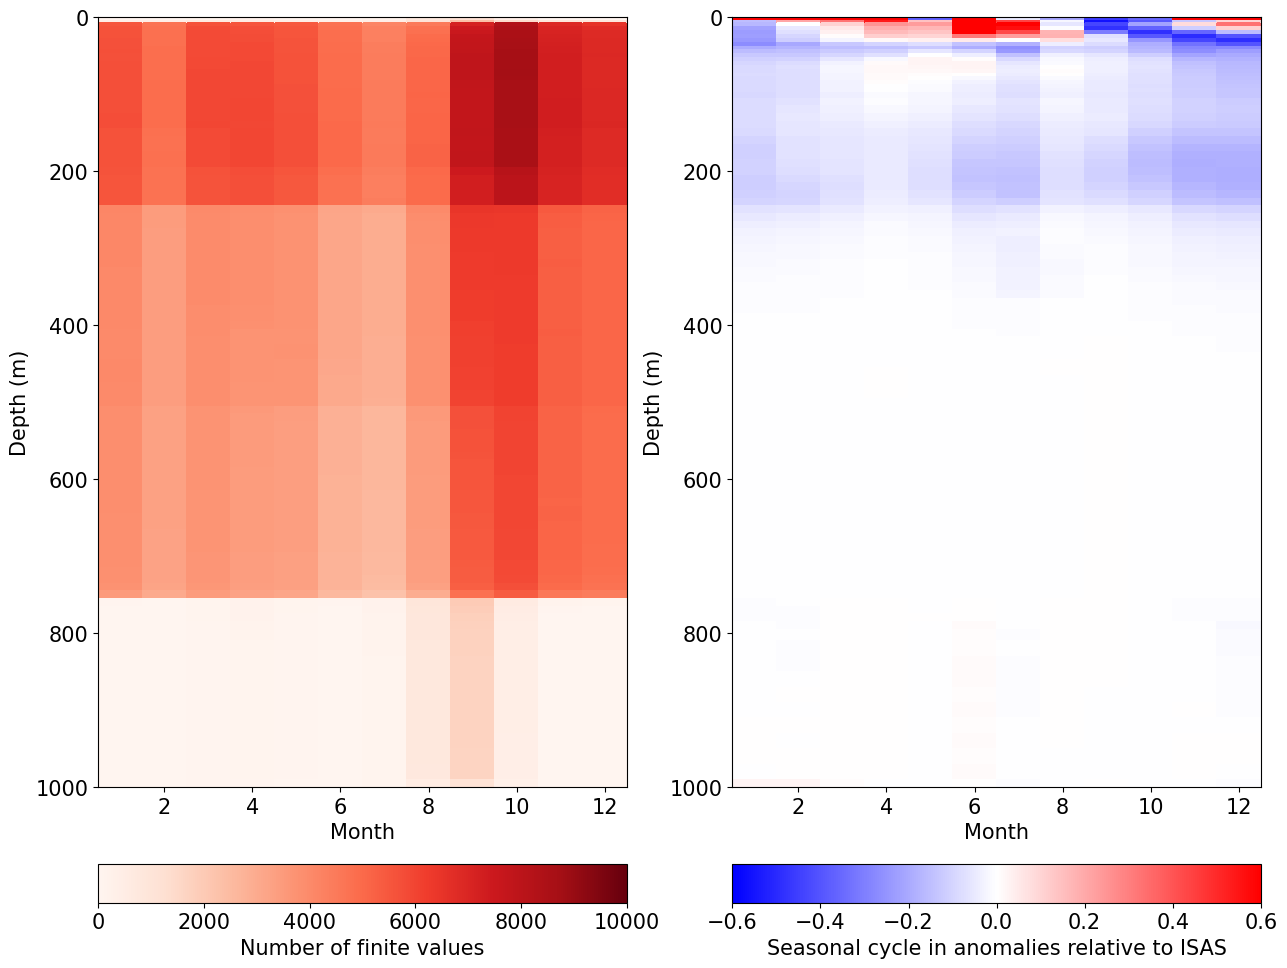

In [10]:



f,ax = plt.subplots(1,2,figsize=[15,10])
ftz=15
ax=ax.ravel()
cax0 = inset_axes(ax[0],
                   width="100%",  # width = 5% of parent_bbox width
                   height="5%",  # height : 50%
                   loc='lower left',
                   bbox_to_anchor=(0, -0.15, 1, 1),
                   bbox_transform=ax[0].transAxes,
                   borderpad=0,
                   )
cax1 = inset_axes(ax[1],
                   width="100%",  # width = 5% of parent_bbox width
                   height="5%",  # height : 50%
                   loc='lower left',
                   bbox_to_anchor=(0, -0.15, 1, 1),
                   bbox_transform=ax[1].transAxes,
                   borderpad=0,
                   )



p0=ax[0].pcolor(np.arange(1,13,1),
          profiles_anom_amerasian_psal.depth.values,
          profiles_anom_amerasian_psal.salinity_QC_anom.groupby(months).count('profile').values.T,cmap=plt.cm.Reds,vmin=0,vmax =10000)

ax[0].invert_yaxis()
ax[0].set_ylim([1000,0])
ax[0].set_ylabel('Depth (m)',fontsize=ftz)
ax[0].tick_params(labelsize=ftz)
ax[0].set_xlabel('Month',fontsize=ftz)
cbar = plt.colorbar(p0,cax0,orientation='horizontal')
cbar.ax.tick_params(labelsize=ftz)
cbar.set_label('Number of finite values', size=ftz)






p1=ax[1].pcolor(np.arange(1,13,1),
          profiles_anom_amerasian_psal.depth.values,
          profiles_anom_amerasian_psal.salinity_QC_anom.groupby(months).mean('profile').values.T,vmin=-0.6,vmax=0.6,cmap=plt.cm.bwr)

ax[1].invert_yaxis()
ax[1].set_ylim([1000,0])
ax[1].set_ylabel('Depth (m)',fontsize=ftz)
ax[1].tick_params(labelsize=ftz)
ax[1].set_xlabel('Month',fontsize=ftz)

cbar = plt.colorbar(p1,cax1,orientation='horizontal')
cbar.ax.tick_params(labelsize=ftz)
cbar.set_label('Seasonal cycle in anomalies relative to ISAS', size=ftz)




   
plt.savefig('/home/aprigent/Documents/Projects/Analysis_obs/figures/fig_seasonal_cycle_PSAL_anomalies_amerasian_level3.png',bbox_inches='tight',dpi=300)